# Sentiment Analysis of IMDB Reviews with Baseline and Transformer Models

This notebook:
- Loads the IMDB dataset
- Splits it into 70% train, 15% validation, 15% test
- Defines a baseline model (Logistic Regression with TF-IDF)
- Defines a transformer model (e.g., DistilBERT / BERT / RoBERTa)
- Trains both models on the training set
- Evaluates both models on the test set
- Displays metrics and comparison tables

## How to run this notebook

1. Install dependencies:

   ```bash
   pip install -r requirements.txt


Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, classification_report
)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW



Load IMDB Dataset

In [ ]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df = df.sample(10000, random_state=42)


Convert labels to numeric

In [ ]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
texts = df['review'].tolist()
labels = df['sentiment'].tolist()


Split into 70/15/15

In [ ]:
# 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.15, random_state=42, stratify=labels
)

# 15% validation from remaining 85%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(len(X_train), len(X_val), len(X_test))


6999 1501 1500


Baseline: TF‑IDF + Logistic Regression

In [ ]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train_tfidf, y_train)

y_pred_base = baseline.predict(X_test_tfidf)
y_proba_base = baseline.predict_proba(X_test_tfidf)[:, 1]

acc = accuracy_score(y_test, y_pred_base)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_base, average="macro")
roc = roc_auc_score(y_test, y_proba_base)

print("=== Baseline (TF-IDF + Logistic Regression) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-macro:  {f1:.4f}")
print(f"ROC-AUC:   {roc:.4f}")


=== Baseline (TF-IDF + Logistic Regression) ===
Accuracy:  0.8633
Precision: 0.8639
Recall:    0.8632
F1-macro:  0.8632
ROC-AUC:   0.9458


Baseline Confusion Matrix

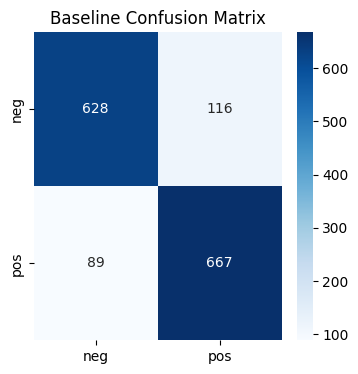

In [ ]:
cm = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["neg","pos"], yticklabels=["neg","pos"])
plt.title("Baseline Confusion Matrix")
plt.show()


Transformer Dataset Class

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


Prepare Transformer DataLoaders

In [ ]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_ds = TextDataset(X_train, y_train, tokenizer)
val_ds   = TextDataset(X_val, y_val, tokenizer)
test_ds  = TextDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8)
test_loader  = DataLoader(test_ds, batch_size=8)


Load DistilBERT Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 1

total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training & Evaluation Functions

In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            labels.extend(batch["labels"].numpy())
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
            probs.extend(torch.softmax(logits, dim=-1)[:,1].cpu().numpy())
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    roc = roc_auc_score(labels, probs)
    return acc, prec, rec, f1, roc


Train DistilBERT

In [ ]:
for epoch in range(epochs):
    loss = train_epoch(model, train_loader)
    val_acc, val_prec, val_rec, val_f1, val_roc = eval_epoch(model, val_loader)
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {loss:.4f}")
    print(f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Val ROC-AUC: {val_roc:.4f}")
    print("-"*40)


Epoch 1/1
Train Loss: 0.4067
Val Acc: 0.8448 | Val F1: 0.8446 | Val ROC-AUC: 0.9336
----------------------------------------


Final Test Evaluation

In [ ]:
test_acc, test_prec, test_rec, test_f1, test_roc = eval_epoch(model, test_loader)

print("=== DistilBERT Test Results ===")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-macro:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc:.4f}")


=== DistilBERT Test Results ===
Accuracy:  0.8447
Precision: 0.8448
Recall:    0.8446
F1-macro:  0.8446
ROC-AUC:   0.9261


Transformer Confusion Matrix

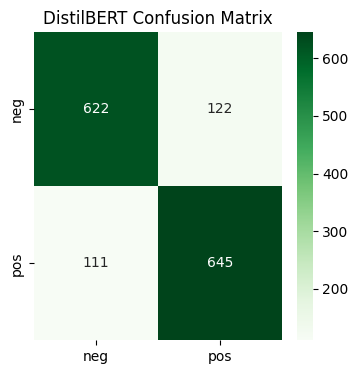

In [ ]:
# Get predictions again
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        all_labels.extend(batch["labels"].numpy())
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["neg","pos"], yticklabels=["neg","pos"])
plt.title("DistilBERT Confusion Matrix")
plt.show()


Comparison Table

In [ ]:
results = pd.DataFrame([
    ["TF-IDF + Logistic Regression", acc, prec, rec, f1, roc],
    ["DistilBERT", test_acc, test_prec, test_rec, test_f1, test_roc]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1-macro", "ROC-AUC"])

results


,Model,Accuracy,Precision,Recall,F1-macro,ROC-AUC
0,TF-IDF + Logistic Regression,0.863333,0.863862,0.863181,0.863241,0.945797
1,DistilBERT,0.844667,0.844753,0.844598,0.844630,0.926078
